Image converted to grayscale successfully.
Grayscale image shape: (240, 320)


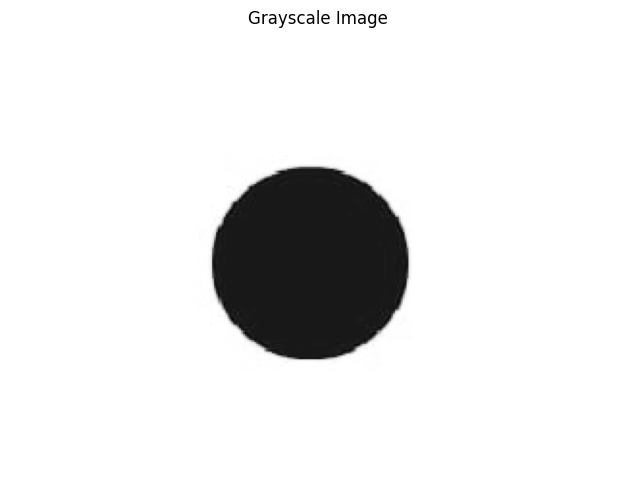

In [3]:
# --- 2. Convert to Grayscale ---
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print("Image converted to grayscale successfully.")
print(f"Grayscale image shape: {gray_img.shape}")

# Display the grayscale image
plt.figure(figsize=(8, 6))
plt.imshow(gray_img, cmap='gray') # Use 'gray' colormap for grayscale images
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

Optimal threshold value determined by Otsu: 165.0
Image binarized successfully.


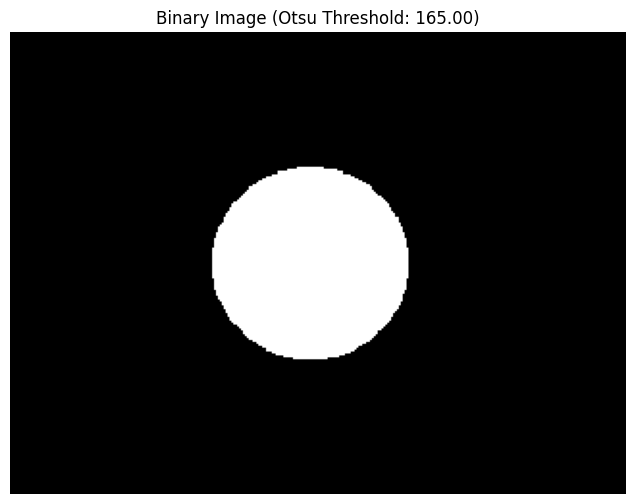

In [4]:
# --- 3. Determine and Apply Threshold (Otsu's Binarization) ---
# cv2.THRESH_OTSU finds the optimal threshold value automatically.
# cv2.THRESH_BINARY_INV means:
#   If pixel_value > threshold, set to 0 (black)
#   If pixel_value <= threshold, set to 255 (white)
# This is suitable for darker objects on a lighter background.
ret, binary_img = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

print(f"Optimal threshold value determined by Otsu: {ret}")
print("Image binarized successfully.")

# Display the binary image
plt.figure(figsize=(8, 6))
plt.imshow(binary_img, cmap='gray') # Use 'gray' colormap for binary images
plt.title(f'Binary Image (Otsu Threshold: {ret:.2f})')
plt.axis('off')
plt.show()


Applied morphological opening.
Applied morphological closing.


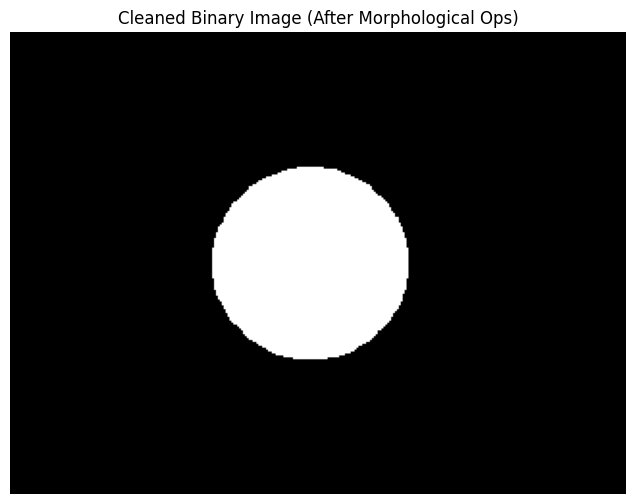

In [5]:

# --- 4. Optional: Morphological Operations (for noise reduction/cleanup) ---

# Define a kernel for morphological operations
# A 5x5 elliptical kernel is often good for circular shapes
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Apply Opening to remove small white noise outside the bullseye
# This is erosion followed by dilation
opened_img = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel)
print("Applied morphological opening.")

# Apply Closing to fill small black holes inside the bullseye
# This is dilation followed by erosion
cleaned_binary_img = cv2.morphologyEx(opened_img, cv2.MORPH_CLOSE, kernel)
print("Applied morphological closing.")


# Display the cleaned binary image
plt.figure(figsize=(8, 6))
plt.imshow(cleaned_binary_img, cmap='gray')
plt.title('Cleaned Binary Image (After Morphological Ops)')
plt.axis('off')
plt.show()


Found 1 contours.


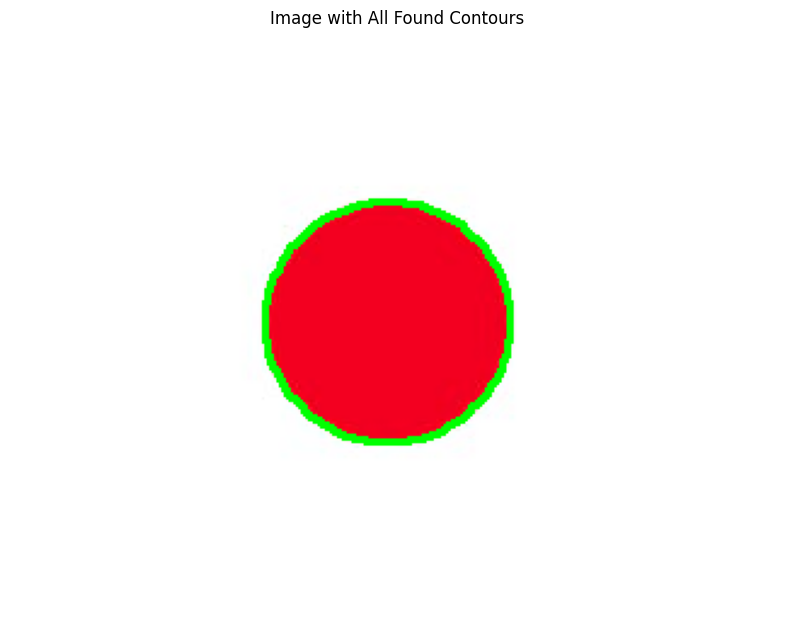

In [6]:

# --- 5. Find Contours ---

# cv2.findContours can modify the input image, so we often pass a copy.
# RETR_EXTERNAL retrieves only the outermost contours (perfect for our single bullseye blob).
# CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments, saving memory.
contours, hierarchy = cv2.findContours(cleaned_binary_img.copy(),
                                       cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)

print(f"Found {len(contours)} contours.")

# Create a copy of the original image to draw contours on
img_with_contours = img.copy()

# Draw all found contours on the original image (optional, for visualization)
# -1 means draw all contours, (0, 255, 0) is green color, 2 is thickness
cv2.drawContours(img_with_contours, contours, -1, (0, 255, 0), 2)

# Display the image with contours
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_contours, cv2.COLOR_BGR2RGB))
plt.title('Image with All Found Contours')
plt.axis('off')
plt.show()

Bullseye contour successfully isolated.


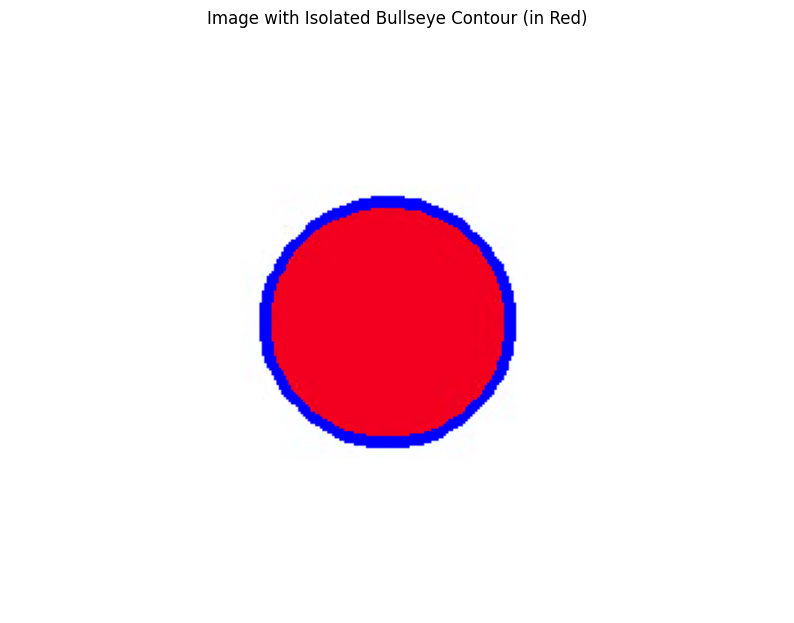

In [7]:
# --- 6. Isolate the Bullseye Contour ---

bullseye_contour = None

if len(contours) > 0:
    # Since you reported 1 contour, this will just pick that one.
    # In a more general case, you'd pick the largest by area:
    # bullseye_contour = max(contours, key=cv2.contourArea)

    # For now, if only one is found, it must be our bullseye
    bullseye_contour = contours[0]
    print("Bullseye contour successfully isolated.")

    # Optional: Draw the isolated bullseye contour on a copy of the original image
    img_with_isolated_contour = img.copy()
    cv2.drawContours(img_with_isolated_contour, [bullseye_contour], -1, (255, 0, 0), 3) # Red color, thicker line
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_with_isolated_contour, cv2.COLOR_BGR2RGB))
    plt.title('Image with Isolated Bullseye Contour (in Red)')
    plt.axis('off')
    plt.show()
else:
    print("No contours found. Cannot isolate bullseye.")

Bullseye center (cX, cY): (155, 119)


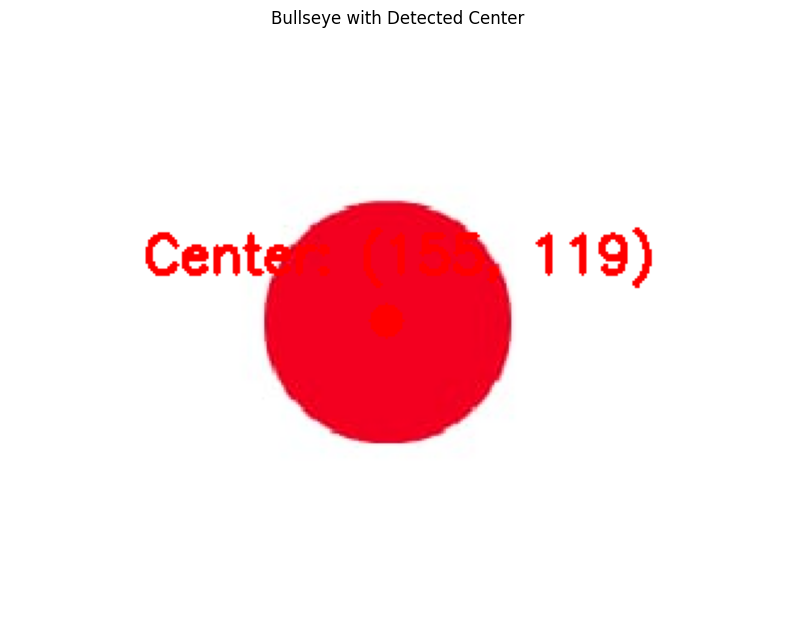


Final bullseye center coordinates: (155, 119)


In [8]:

# --- 7. Calculate Centroid (Center of Mass) ---

if bullseye_contour is not None:
    # Calculate image moments for the bullseye contour
    M = cv2.moments(bullseye_contour)

    # Check if the mass (M["m00"]) is not zero to avoid division by zero
    if M["m00"] != 0:
        # Calculate x, y coordinates of the centroid
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        bullseye_center = (cX, cY)
        print(f"Bullseye center (cX, cY): {bullseye_center}")

        # --- 8. Optional: Visualization (Draw center on original image) ---
        img_with_center = img.copy()

        # Draw a circle at the center
        cv2.circle(img_with_center, bullseye_center, 7, (0, 0, 255), -1) # Red circle, filled

        # Draw a text label for the center coordinates
        cv2.putText(img_with_center, f"Center: ({cX}, {cY})", (cX - 100, cY - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        # Display the image with the detected center
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(img_with_center, cv2.COLOR_BGR2RGB))
        plt.title('Bullseye with Detected Center')
        plt.axis('off')
        plt.show()

    else:
        print("Error: Could not calculate centroid (mass of contour is zero).")
        bullseye_center = None
else:
    print("Error: Bullseye contour not found. Cannot calculate centroid.")
    bullseye_center = None

# The 'bullseye_center' variable now holds the (x, y) coordinates of the center.
# You can use this variable for further integration.
print(f"\nFinal bullseye center coordinates: {bullseye_center}")